In [5]:
from langgraph.graph import StateGraph
from typing import TypedDict
from langgraph.graph import StateGraph,MessagesState,START,END

### Simple workflow

In [3]:
# define state
# Typed dictionaries are special dictionaries where we can tell the data types

class BMIState(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float


In [4]:
def calculate_bmi(state:BMIState) -> BMIState:
    ''' argument : always a State object
        return type hint :  State Object
        return type : Updated State Object'''

    # extract vaue from the state
    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    # update state dictionary variable
    state['bmi'] = round(bmi,2)

    return state

In [7]:
# define you graph
graph = StateGraph(BMIState)

# add nodes to your graph
graph.add_node('calculate_bmi', calculate_bmi)

# add edges to you graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi', END)

# compile the graph
workflow = graph.compile()




In [8]:
# execute the graph
initial_state = {'weight_kg':90, 'height_m':1.73}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 90, 'height_m': 1.73, 'bmi': 30.07}


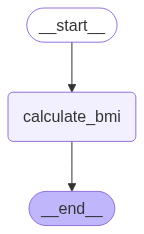

In [9]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

### Workflow with category
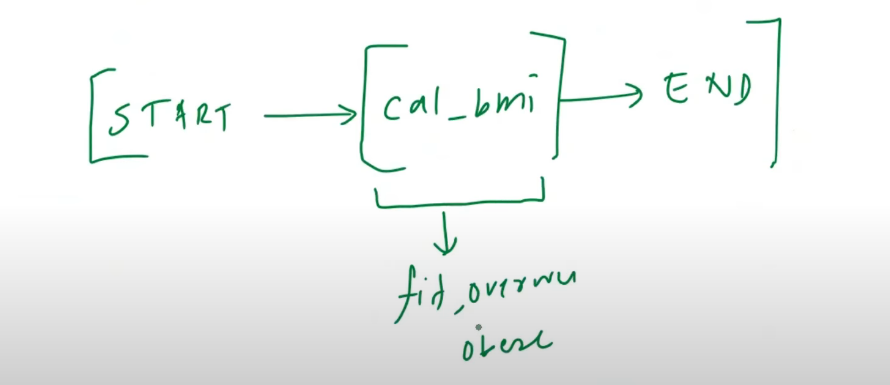

In [11]:
# define state
# Typed dictionaries are special dictionaries where we can tell the data types

class BMIState(TypedDict):

    weight_kg: float
    height_m: float
    bmi: float
    category : str

In [12]:
def calculate_bmi(state:BMIState) -> BMIState:
    ''' argument : always a State object
        return type hint :  State Object
        return type : Updated State Object'''

    # extract vaue from the state
    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    # update state dictionary variable
    state['bmi'] = round(bmi,2)

    return state

In [13]:
def label_bmi(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [14]:
# define you graph
graph = StateGraph(BMIState)

# add nodes to your graph
graph.add_node('calculate_bmi', calculate_bmi)
graph.add_node('label_bmi', label_bmi)

# add edges to you graph
graph.add_edge(START, 'calculate_bmi')
graph.add_edge('calculate_bmi','label_bmi')
graph.add_edge('calculate_bmi', END)

# compile the graph
workflow = graph.compile()




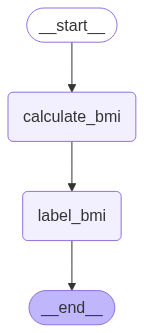

In [15]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

In [16]:
# execute the graph
initial_state = {'weight_kg':90, 'height_m':1.73}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 90, 'height_m': 1.73, 'bmi': 30.07, 'category': 'Obese'}
